In [1]:
# STEP 0: IMPORTS

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

In [3]:
# STEP 1: URL

In [4]:
url = "https://stats.espncricinfo.com/ci/engine/stats/index.html?class=2;template=results;type=batting"
base_url="https://stats.espncricinfo.com/ci/engine/stats/index.html?class=2;template=results;type=batting&page={}"

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9"
}

response = requests.get(url, headers=headers)

print("Status Code:", response.status_code)

Status Code: 200


In [5]:
# STEP 3: PARSE

In [6]:
soup = BeautifulSoup(response.text, "html.parser")

In [7]:
# STEP 4: FIND TABLE

In [8]:
tables = soup.find_all("table")

print("Total tables found:", len(tables))

# Select correct table (usually 3rd one)
table = tables[2]

rows = table.find_all("tr")


Total tables found: 8


In [9]:
 # STEP 5: HEADERS

In [10]:

headers = [th.text.strip() for th in rows[0].find_all("th")]

print("Headers:", headers) # Column Names

Headers: ['Player', 'Span', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100', '50', '0', '']


In [11]:
# STEP 6: EXTRACT DATA (SAFE)

In [48]:
# Pagination Code

all_data = []

req_headers = {"User-Agent": "Mozilla/5.0"}

for page in range(1, 11):   # 5 pages → ~500 rows
    print(f"Scraping page {page}...")
    
    url = base_url.format(page)
    response = requests.get(url, headers=req_headers)
    soup = BeautifulSoup(response.text, "html.parser")
    
    tables = soup.find_all("table")
    
    # find correct table
    for t in tables:
        if "Player" in str(t):
            table = t
            break
    
    rows = table.find_all("tr")
    
    # extract headers only once
    if page == 1:
        headers = [th.text.strip() for th in rows[0].find_all("th")]
    
    for row in rows[1:]:
        cols = row.find_all("td")
        
        if len(cols) == len(headers):
            all_data.append([col.text.strip() for col in cols])

Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...


In [13]:
print(type(req_headers))

<class 'dict'>


In [14]:
# STEP 7: DATAFRAME

In [20]:
df = pd.DataFrame(all_data, columns=headers)

In [55]:
# Export to CSV

In [ ]:
df.to_csv("cricket_stats.csv", index=False)

In [ ]:
# Read CSV again

In [56]:
df = pd.read_csv("cricket_stats.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.info())

Rows: 500
Columns: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player       500 non-null    object 
 1   Span         500 non-null    object 
 2   Mat          500 non-null    int64  
 3   Inns         500 non-null    int64  
 4   NO           500 non-null    int64  
 5   Runs         500 non-null    int64  
 6   HS           314 non-null    float64
 7   Ave          500 non-null    float64
 8   BF           500 non-null    int64  
 9   SR           500 non-null    float64
 10  100          500 non-null    int64  
 11  50           500 non-null    int64  
 12  0            500 non-null    int64  
 13  Unnamed: 13  0 non-null      float64
dtypes: float64(4), int64(8), object(2)
memory usage: 54.8+ KB
None


In [21]:
df

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,
0,SR Tendulkar (IND),1989-2012,463,452,41,18426,200*,44.83,21368,86.23,49,96,20,
1,V Kohli (IND),2008-2026,311,299,47,14797,183,58.71,15771,93.82,54,77,18,
2,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,
3,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,
4,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.2,28,68,34,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,GM Ritchie (AUS),1982-1987,44,42,7,959,84,27.4,1479,64.84,0,6,2,
496,JN Malan (SA),2020-2022,23,22,2,958,177*,47.9,1150,83.3,3,4,2,
497,MG Bracewell (NZ),2022-2026,43,37,11,956,140,36.76,874,109.38,2,3,1,
498,RR Watson (SCOT),2006-2010,35,35,4,956,123*,30.83,1286,74.33,1,6,4,


In [22]:
top_player = df.loc[df["Runs"].idxmax()]
print(top_player)

Player    B Sharki (NEP)
Span           2022-2026
Mat                   37
Inns                  34
NO                     3
Runs                 995
HS                  101*
Ave                32.09
BF                  1463
SR                 68.01
100                    1
50                     4
0                      2
                        
Name: 475, dtype: object


In [23]:
# Check Data shape
print(df.shape)

(500, 14)


In [24]:
# Check Column Names
print(df.columns)

Index(['Player', 'Span', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR',
       '100', '50', '0', ''],
      dtype='object')


In [25]:
 # removes empty column:-because sometimes extra blank <th> or <td> exists which leads to emppty columns.
df=df.loc[:,df.columns !=''] 

In [27]:
df = df.copy()
df['HS'] = df['HS'].astype(str).str.replace('*', '', regex=False)
df['HS'] = pd.to_numeric(df['HS'], errors='coerce')

In [28]:
df["Runs"] = pd.to_numeric(df["Runs"], errors="coerce")
df["Ave"] = pd.to_numeric(df["Ave"], errors="coerce")
df["SR"] = pd.to_numeric(df["SR"], errors="coerce")

In [29]:
df = pd.DataFrame(all_data, columns=headers)

print(df.head())

                        Player       Span  Mat Inns  NO   Runs    HS    Ave  \
0           SR Tendulkar (IND)  1989-2012  463  452  41  18426  200*  44.83   
1                V Kohli (IND)  2008-2026  311  299  47  14797   183  58.71   
2  KC Sangakkara (Asia/ICC/SL)  2000-2015  404  380  41  14234   169  41.98   
3         RT Ponting (AUS/ICC)  1995-2012  375  365  39  13704   164  42.03   
4      ST Jayasuriya (Asia/SL)  1989-2011  445  433  18  13430   189  32.36   

      BF     SR 100  50   0    
0  21368  86.23  49  96  20    
1  15771  93.82  54  77  18    
2  18048  78.86  25  93  15    
3  17046  80.39  30  82  20    
4  14725   91.2  28  68  34    


In [30]:
print(df.columns)

Index(['Player', 'Span', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR',
       '100', '50', '0', ''],
      dtype='object')


df.columns=df.columns.str.strip()

In [31]:
# STEP 8: CLEANING

In [32]:
# Handle "-" values 
df.replace("-", np.nan, inplace=True)



In [ ]:
# Convert Numeric Columns

In [33]:
numeric_cols = ['Mat', 'Inns', 'NO', 'Runs', 'Ave', 'BF', 'SR', '100', '50', '0']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [34]:
# Clean player column

In [47]:

df['Player']=df['Player'].str.replace(r"[^a-zA-Z\s]","",regex=True)

In [36]:
# Removing Duplicates
df.drop_duplicates(inplace=True)

In [37]:
print(df.describe())
print(df.isnull().sum()) # Final Null Check

              Mat        Inns         NO          Runs          HS  \
count  500.000000  500.000000  500.00000    500.000000  314.000000   
mean   122.026000  110.028000   15.06800   3164.180000  118.831210   
std     81.345335   74.092852   14.41996   2637.422633   33.701473   
min     22.000000   21.000000    0.00000    955.000000   37.000000   
25%     59.000000   55.750000    5.00000   1342.750000   98.000000   
50%     92.500000   85.000000   10.00000   2088.500000  115.000000   
75%    164.000000  142.250000   21.00000   3893.750000  140.000000   
max    463.000000  452.000000   84.00000  18426.000000  264.000000   

              Ave            BF          SR         100          50  \
count  500.000000    500.000000  500.000000  500.000000  500.000000   
mean    32.253900   4062.600000   78.456620    4.138000   18.194000   
std      8.753536   3277.227102   13.036088    6.176022   16.691002   
min     10.300000    794.000000   49.220000    0.000000    0.000000   
25%     25.712

In [38]:
# STEP 9: EDA

In [39]:
# Check Column Names
print(df.columns)

Index(['Player', 'Span', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR',
       '100', '50', '0', ''],
      dtype='object')


In [40]:
# Check for DataTypes
print(df.dtypes)

Player     object
Span       object
Mat         int64
Inns        int64
NO          int64
Runs        int64
HS        float64
Ave       float64
BF          int64
SR        float64
100         int64
50          int64
0           int64
           object
dtype: object


# 1.Histogram(runs distribution)

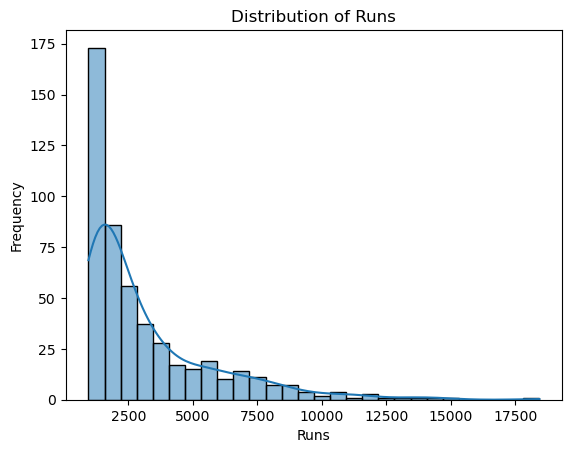

In [41]:
plt.figure()


sns.histplot(df["Runs"],kde=True)

plt.title("Distribution of Runs")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

# INTERPRETATION

# The distribution of runs is positively skewed, indicating that most players have lower run totals, while a few players dominate with exceptionally high scores.

# 2.Boxplot

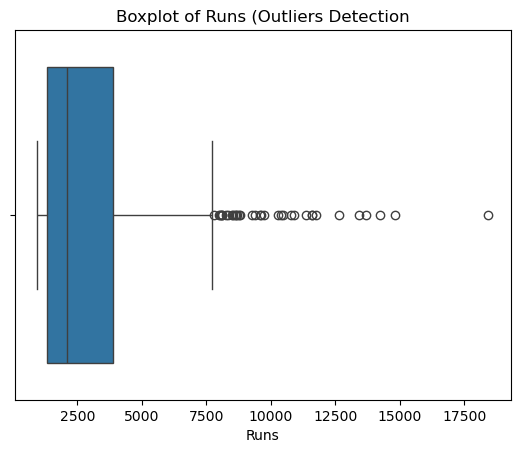

In [42]:
plt.figure()

sns.boxplot(x=df["Runs"])

plt.title("Boxplot of Runs (Outliers Detection")
plt.xlabel("Runs")
plt.show()

# INTERPRETAION

# The boxplot shows a wide spread in runs, with several extreme outliers on the higher end. This indicates that a small number of players have significantly higher run totals compared to the majority.

# 3.Scatter Plot


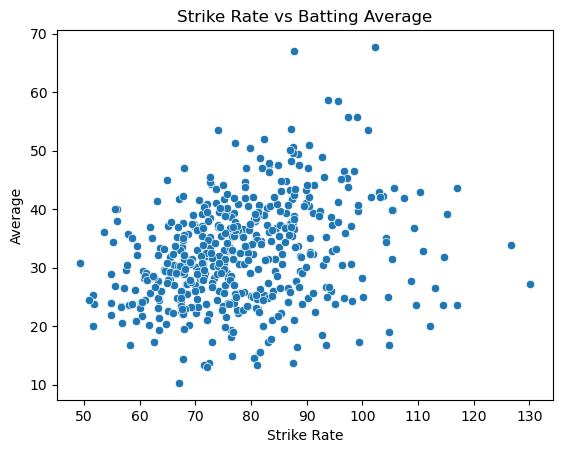

In [43]:
plt.figure()

sns.scatterplot(x=df["SR"], y=df["Ave"])

plt.title("Strike Rate vs Batting Average")
plt.xlabel("Strike Rate")
plt.ylabel("Average")
plt.show()

# INTERPRETAION

# The scatter plot shows the relationship between strike rate and batting average. A slight positive trend can be observed, indicating that players with higher strike rates often tend to maintain better averages, though the relationship is not very strong.

# 4.regplot

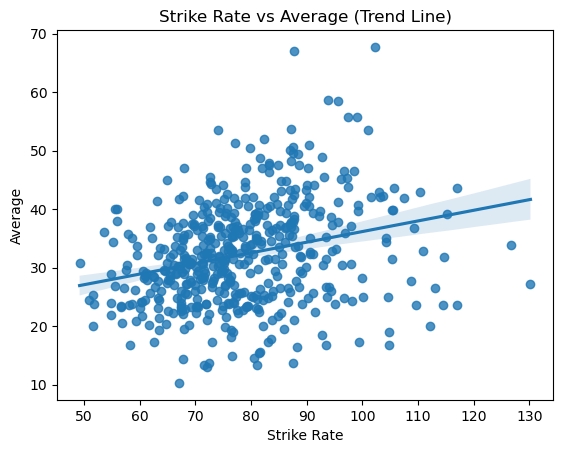

In [44]:
plt.figure()

sns.regplot(x=df["SR"], y=df["Ave"])

plt.title("Strike Rate vs Average (Trend Line)")
plt.xlabel("Strike Rate")
plt.ylabel("Average")

plt.show()

# INTERPRETAION

# 🔹 **1. Trend Line Direction**

Line is slightly upward

👉 Positive relationship


🔹 **2. Strength of Relationship**

Points are widely spread

👉 Weak correlation


🔹 **3. Real Meaning**

Some players:

High SR + High Avg  (elite)

High SR + Low Avg (aggressive but inconsistent)

Low SR + High Avg  (slow but stable)


🔹 **4. Outliers**

Few points far away from line

👉 Exceptional or unusual players  

# 5.Bar plot(Top 10 Players by Runs)


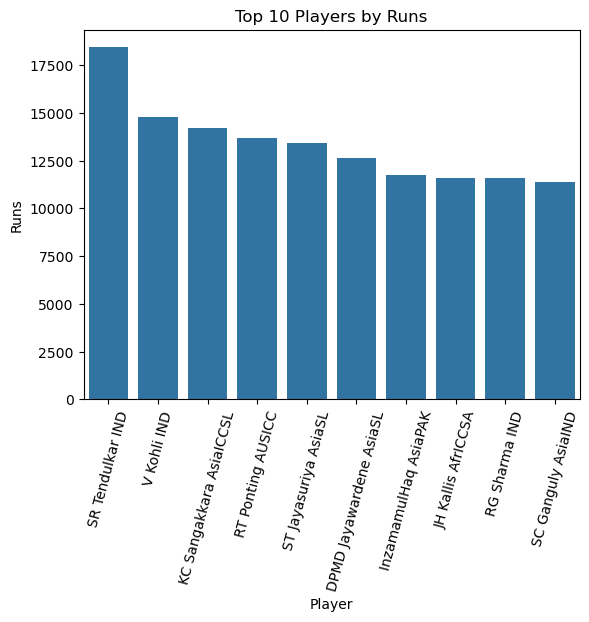

In [45]:
plt.figure()

top10 = df.sort_values(by="Runs", ascending=False).head(10)

sns.barplot(x=top10["Player"], y=top10["Runs"])

plt.title("Top 10 Players by Runs")
plt.xlabel("Player")
plt.ylabel("Runs")

plt.xticks(rotation=75)

plt.show()

# INTERPRETAION

# The bar chart highlights the top 10 players based on total runs scored. It is evident that a few players significantly outperform others, indicating dominance in ODI cricket. The gap between the highest run-scorer and the rest shows that elite players contribute disproportionately to total runs.

# 6.Heatmap(Correlation Matrix)

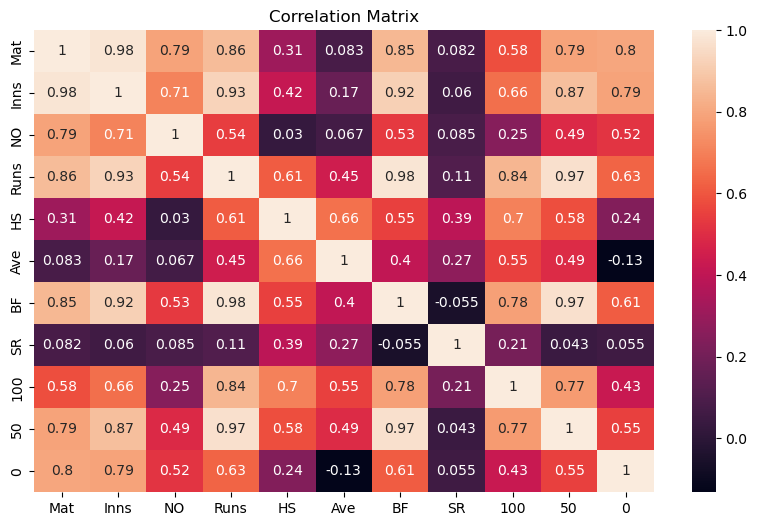

In [46]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")

plt.show()

# INTERPRETAION

# The heatmap shows the correlation between numerical features. Runs has a strong positive correlation with Balls Faced (BF) and Matches (Mat), indicating that players who play more matches and face more balls tend to score more runs. Batting Average also shows a moderate positive relationship with Runs. Strike Rate has a weaker correlation with Runs, suggesting that scoring speed is less directly related to total runs compared to consistency and playtime.